In [1]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


## Q4 (b)

In [20]:
n = 2 # dimension
A = np.array([[1, 1], [0, 0.95]])
b = np.array([0, 0.1])
xdest = np.array([10, 0])
N = 20

### (i)

### Way 1

In [37]:
# Define variables
u = cp.Variable(N)
x = cp.Variable((n, N+1))

# Define objective
objective = cp.Minimize(cp.sum(cp.maximum(cp.abs(u), 2*cp.abs(u) - 1)))

# Define constraints
constraints = [x[:, 0] == 0]
for i in range(1, N+1):
    constraints.append(x[:, i] == np.matmul(A, x[:, i-1]) + b*u[i-1])
constraints.append(x[:, -1] == xdest)

# Formulate the problem
problem = cp.Problem(objective, constraints)

# Solve the problem
problem.solve()


np.float64(15.911948954592829)

In [41]:
u.value

array([ 3.22798702e+00,  1.00000003e+00,  1.00000003e+00,  1.00000002e+00,
        1.00000000e+00,  9.99999994e-01,  9.99999954e-01,  2.12268854e-07,
        1.00888582e-08,  6.73913183e-09,  4.11443654e-09,  1.76160849e-09,
       -3.96562494e-10, -2.82155209e-09, -6.42606156e-09, -1.73248546e-08,
       -9.99999963e-01, -1.00000000e+00, -1.00000002e+00, -1.22798727e+00])

### Way 2

In [7]:
# Define variables
t = np.array([[cp.Variable() for _ in range(4)] for _ in range(N)]) # N*4 for t1, t2, t3, t4

# Define objective
sum_ft = 0
for i in range(N):
    sum_ft += (t[i][0] + t[i][1] + t[i][2] + t[i][3]) # f(u)=t1+t2+t3+t4
objective = cp.Minimize(sum_ft)

# Define constraints
constraints = []
sum = 0
term = b
for i in range(N-1, -1, -1):
    sum+=(t[i][0]-t[i][1])*term # u=t1-t2
    term = np.matmul(A, term) # b, Ab, A2b, ...
constraints.append(cp.constraints.zero.Zero(xdest-sum))

for i in range(N): # t1,t2,t3,t4>=0, t3>=t1-1, t4>=t2-1
    # t1,t2,t3,t4>=0
    for j in range(4):
        constraints.append(t[i][j]>=0)
    # t3>=t1-1
    constraints.append(t[i][2]>=t[i][0]-1)
    # t4>=t2-1
    constraints.append(t[i][3]>=t[i][1]-1)

# Formulate the problem
problem = cp.Problem(objective, constraints)

# Solve the problem
problem.solve()


np.float64(15.91194887443342)

In [8]:
var_values = np.zeros((N, 4))
u_values = np.zeros(N)
for i in range(N):
    for j in range(4):
        temp = round(float(t[i][j].value), 4)
        var_values[i][j] = temp
        # u = t1-t2 => u[i] = t[i][0] - t[i][1]
        if(j==0):
            u_values[i] += temp # u[i] = u[i] + t[i][0] = t[i][0]
        elif(j==1):
            u_values[i] -= temp # u[i] = u[i] - t[i][1] = t[i][0] - t[i][1]
print("t variable values")
print(var_values)
print("\n")
print("u variable values: Optimal Solution")
print(u_values)
print("\n")
print("Optimal Value")
print(problem.value)

t variable values
[[ 3.228 -0.     2.228 -0.   ]
 [ 1.    -0.     0.    -0.   ]
 [ 1.    -0.     0.    -0.   ]
 [ 1.    -0.     0.    -0.   ]
 [ 1.    -0.     0.    -0.   ]
 [ 1.    -0.     0.    -0.   ]
 [ 1.    -0.     0.    -0.   ]
 [ 0.    -0.    -0.    -0.   ]
 [ 0.    -0.    -0.    -0.   ]
 [ 0.    -0.    -0.    -0.   ]
 [ 0.    -0.    -0.    -0.   ]
 [ 0.    -0.    -0.    -0.   ]
 [-0.     0.    -0.    -0.   ]
 [-0.     0.    -0.    -0.   ]
 [-0.     0.    -0.    -0.   ]
 [-0.     0.    -0.    -0.   ]
 [-0.     1.    -0.     0.   ]
 [-0.     1.    -0.     0.   ]
 [-0.     1.    -0.     0.   ]
 [-0.     1.228 -0.     0.228]]


u variable values: Optimal Solution
[ 3.228  1.     1.     1.     1.     1.     1.     0.     0.     0.
  0.     0.     0.     0.     0.     0.    -1.    -1.    -1.    -1.228]


Optimal Value
15.91194887443342


### As seen (from the numbers) above, both: the optimal solution and the optimal value match for the 2 ways.

### (ii)

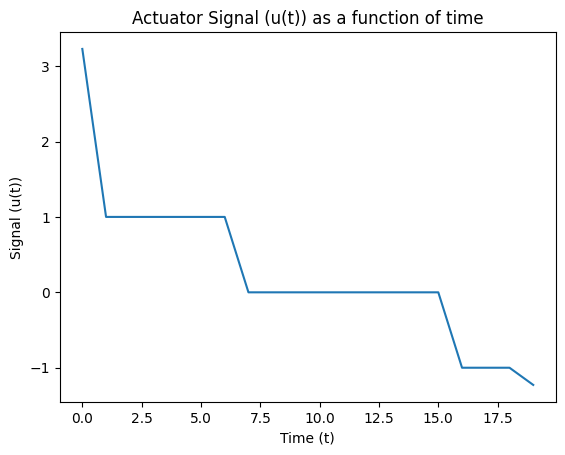

In [18]:
plt.plot(u_values)
plt.xlabel("Time (t)")
plt.ylabel("Signal (u(t))")
plt.title("Actuator Signal (u(t)) as a function of time")
plt.show()

In [13]:
# Building x (position and velocity) data
xdata = np.zeros((n, 21))
for i in range(1, 21):
    xdata[:, i] = np.matmul(A, xdata[:, i-1]) + b*u_values[i-1]

# check: xdata[:, 20] = xdest

In [14]:
xdata

array([[ 0.00000000e+00,  0.00000000e+00,  3.22800000e-01,
         7.29460000e-01,  1.21578700e+00,  1.77779765e+00,
         2.41170777e+00,  3.11392238e+00,  3.88102626e+00,
         4.60977495e+00,  5.30208620e+00,  5.95978189e+00,
         6.58459280e+00,  7.17816316e+00,  7.74205500e+00,
         8.27775225e+00,  8.78666464e+00,  9.27013140e+00,
         9.62942483e+00,  9.87075359e+00,  1.00000159e+01],
       [ 0.00000000e+00,  3.22800000e-01,  4.06660000e-01,
         4.86327000e-01,  5.62010650e-01,  6.33910117e-01,
         7.02214612e-01,  7.67103881e-01,  7.28748687e-01,
         6.92311253e-01,  6.57695690e-01,  6.24810906e-01,
         5.93570360e-01,  5.63891842e-01,  5.35697250e-01,
         5.08912388e-01,  4.83466768e-01,  3.59293430e-01,
         2.41328758e-01,  1.29262320e-01, -7.95613208e-07]])

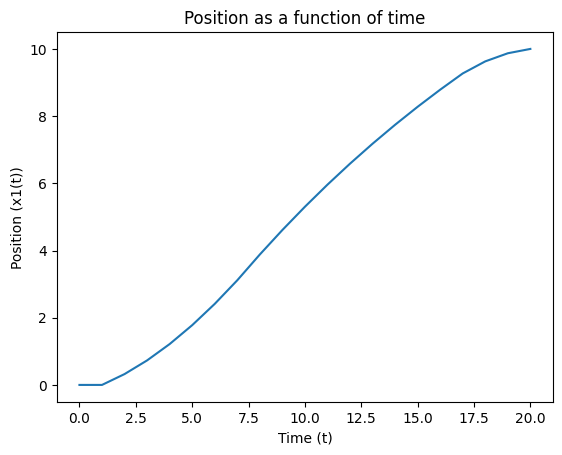

In [17]:
plt.plot(xdata[0, :])
plt.xlabel("Time (t)")
plt.ylabel("Position (x1(t))")
plt.title("Position as a function of time")
plt.show()

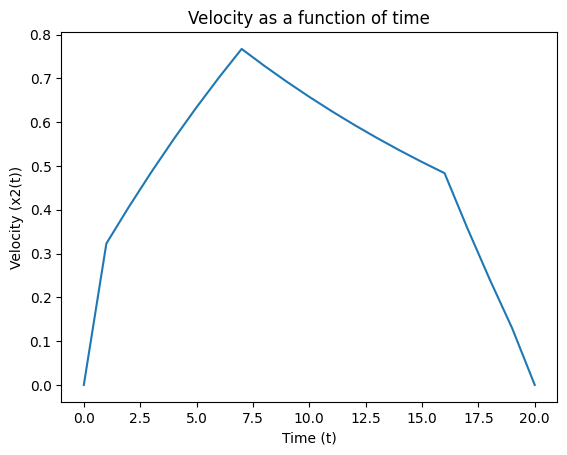

In [16]:
plt.plot(xdata[1, :])
plt.xlabel("Time (t)")
plt.ylabel("Velocity (x2(t))")
plt.title("Velocity as a function of time")
plt.show()